In [7]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
spambase = fetch_ucirepo(id=94) 
  
# data (as pandas dataframes) 
X = spambase.data.features 
y = spambase.data.targets 
  
# metadata 
print(spambase.metadata) 
  
# variable information 
print(spambase.variables) 


{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

# Problem 1: Decision Trees (25 points)

1. Use an existing package to train a decision tree on the *SPAMBASE* training data, without pruning. Use the information gain splitting criteria. Compute the training and the testing error, accuracy, F1 score, and AUC and report these metrics. Write down some observations about the training and testing metrics.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [9]:
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)

y_train_pred = dt_entropy.predict(X_train)
y_test_pred = dt_entropy.predict(X_test)

y_train_prob = dt_entropy.predict_proba(X_train)[:,1]
y_test_prob = dt_entropy.predict_proba(X_test)[:,1]

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Error:", 1 - train_acc)
print("Test Error:", 1 - test_acc)
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Train F1:", f1_score(y_train, y_train_pred))
print("Test F1:", f1_score(y_test, y_test_pred))
print("Train AUC:", roc_auc_score(y_train, y_train_prob))
print("Test AUC:", roc_auc_score(y_test, y_test_prob))

Train Error: 0.00028985507246381825
Test Error: 0.0781928757602085
Train Accuracy: 0.9997101449275362
Test Accuracy: 0.9218071242397915
Train F1: 0.9996319470003681
Test F1: 0.9015317286652079
Train AUC: 0.9999998240470653
Test AUC: 0.9193112078827448


The unpruned decision tree overfits the training data with almost perfect training metrics, but still achieves strong test performance, with a noticeable generalization gap indicating reduced robustness on unseen data.

2. Change the splitting criteria to use the Gini index. and report the same metrics. Compare them to the information gain metrics.

In [10]:
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)

y_train_pred = dt_gini.predict(X_train)
y_test_pred = dt_gini.predict(X_test)

y_train_prob = dt_gini.predict_proba(X_train)[:,1]
y_test_prob = dt_gini.predict_proba(X_test)[:,1]

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Train F1:", f1_score(y_train, y_train_pred))
print("Test F1:", f1_score(y_test, y_test_pred))
print("Train AUC:", roc_auc_score(y_train, y_train_prob))
print("Test AUC:", roc_auc_score(y_test, y_test_prob))

Train Accuracy: 0.9997101449275362
Test Accuracy: 0.9079061685490878
Train F1: 0.9996319470003681
Test F1: 0.8862660944206009
Train AUC: 0.9999998240470653
Test AUC: 0.9082174075174283


Using the Gini index results in near-perfect training performance, indicating severe overfitting, similar to the information gain tree. However, the test accuracy, F1 score, and AUC are slightly lower than those obtained using information gain, suggesting that entropy provides marginally better splits on this dataset. Overall, both criteria produce similar behavior, with the primary issue being overfitting due to the lack of pruning rather than the choice of splitting metric.

3. Implement a pruning criteria that sets an upper bound on the maximum depth of the tree. Generate a graph that plots the training and
testing error as a function of the tree depth on the *SPAMBASE* data. Please explain your observations. What is the optimal depth of the
tree that you would recommend based on this analysis?


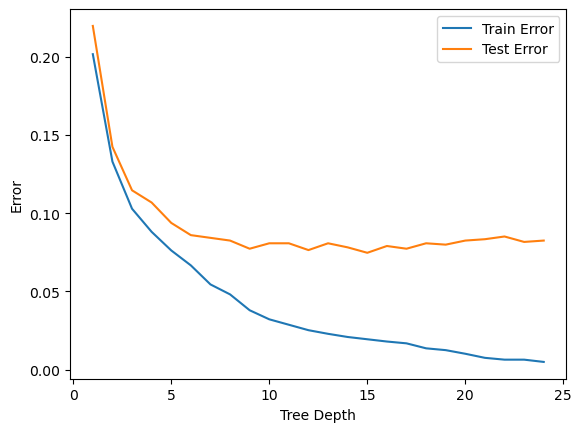

In [11]:
depths = range(1, 25)
train_errors = []
test_errors = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    
    train_errors.append(1 - accuracy_score(y_train, model.predict(X_train)))
    test_errors.append(1 - accuracy_score(y_test, model.predict(X_test)))

plt.plot(depths, train_errors, label="Train Error")
plt.plot(depths, test_errors, label="Test Error")
plt.xlabel("Tree Depth")
plt.ylabel("Error")
plt.legend()
plt.show()